LAB 3: PARSING ALIGNMENT RESULTS AND ADVANCED ANALYSIS

PART 1: Detailed Alignment Parsing

Sequence 1: ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCG
Sequence 2: ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATAA

Alignment score: 116.0

Aligned query:  ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATAA
Aligned target: ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCG

PART 2: Calculating Alignment Statistics

Alignment Statistics:
  Alignment length: 61 bp
  Matches: 59
  Mismatches: 2
  Total gaps: 0
  Query gaps: 0
  Target gaps: 0
  Identity: 96.72%
  Similarity: 100.00%
  Gap percentage: 0.00%
  Score: 116.0

PART 3: Position-by-Position Analysis

First 20 positions:
 position query target  type
        1     A      A match
        2     T      T match
        3     G      G match
        4     C      C match
        5     G      G match
        6     A      A match
        7     T      T match
        8     C      C match
        

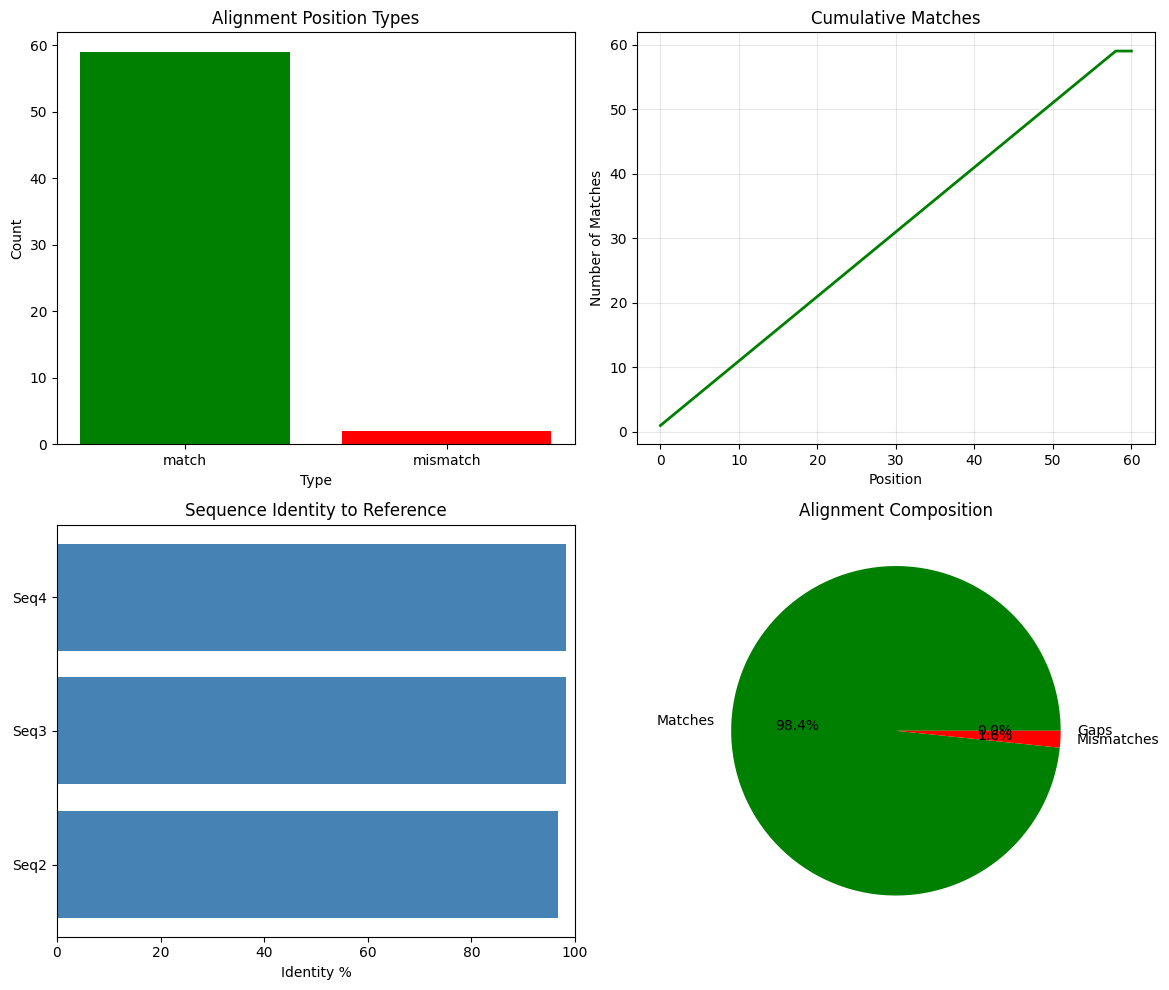


PART 8: Exporting Alignment Results
Exported position-by-position analysis to 'alignment_positions.csv'
Exported sequence comparison to 'sequence_comparison.csv'
Exported alignment to 'alignment_result.fasta'
Exported summary report to 'alignment_report.txt'

Lab 3 Complete!


In [2]:
# Lab: Parsing Alignment Results and Advanced Analysis

import sys

# Run this in Google Colab
!{sys.executable} -m pip install biopython

from Bio import Align
from Bio.Seq import Seq
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 70)
print("LAB 3: PARSING ALIGNMENT RESULTS AND ADVANCED ANALYSIS")
print("=" * 70)

# ===== PART 1: Detailed Alignment Parsing =====
print("\n" + "=" * 70)
print("PART 1: Detailed Alignment Parsing")
print("=" * 70)

# Create aligner and perform alignment
aligner = Align.PairwiseAligner()
aligner.mode = 'global'
aligner.match_score = 2
aligner.mismatch_score = -1
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

seq1 = "ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCG"
seq2 = "ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATAA"

alignments = aligner.align(seq1, seq2)
alignment = alignments[0]

print(f"\nSequence 1: {seq1}")
print(f"Sequence 2: {seq2}")
print(f"\nAlignment score: {alignment.score}")

# Extract aligned sequences
query_aligned = str(alignment.query)
target_aligned = str(alignment.target)

print(f"\nAligned query:  {query_aligned}")
print(f"Aligned target: {target_aligned}")

# ===== PART 2: Calculating Alignment Statistics =====
print("\n" + "=" * 70)
print("PART 2: Calculating Alignment Statistics")
print("=" * 70)

def calculate_alignment_stats(query_aligned, target_aligned, score):
    """Calculate comprehensive alignment statistics"""

    stats = {
        'alignment_length': len(query_aligned),
        'matches': 0,
        'mismatches': 0,
        'gaps_query': 0,
        'gaps_target': 0,
        'total_gaps': 0,
        'score': score
    }

    # Count matches and mismatches
    for q, t in zip(query_aligned, target_aligned):
        if q == '-' or t == '-':
            stats['total_gaps'] += 1
            if q == '-':
                stats['gaps_query'] += 1
            if t == '-':
                stats['gaps_target'] += 1
        elif q == t:
            stats['matches'] += 1
        else:
            stats['mismatches'] += 1

    # Calculate percentages
    stats['identity'] = (stats['matches'] / stats['alignment_length']) * 100
    stats['similarity'] = ((stats['matches'] + stats['mismatches']) /
                          (stats['alignment_length'] - stats['total_gaps'])) * 100
    stats['gap_percentage'] = (stats['total_gaps'] / stats['alignment_length']) * 100

    return stats

stats = calculate_alignment_stats(query_aligned, target_aligned, alignment.score)

print("\nAlignment Statistics:")
print(f"  Alignment length: {stats['alignment_length']} bp")
print(f"  Matches: {stats['matches']}")
print(f"  Mismatches: {stats['mismatches']}")
print(f"  Total gaps: {stats['total_gaps']}")
print(f"  Query gaps: {stats['gaps_query']}")
print(f"  Target gaps: {stats['gaps_target']}")
print(f"  Identity: {stats['identity']:.2f}%")
print(f"  Similarity: {stats['similarity']:.2f}%")
print(f"  Gap percentage: {stats['gap_percentage']:.2f}%")
print(f"  Score: {stats['score']}")

# ===== PART 3: Position-by-Position Analysis =====
print("\n" + "=" * 70)
print("PART 3: Position-by-Position Analysis")
print("=" * 70)

def analyze_positions(query_aligned, target_aligned):
    """Analyze each position in the alignment"""
    positions = []

    for i, (q, t) in enumerate(zip(query_aligned, target_aligned)):
        if q == '-':
            match_type = 'gap_query'
        elif t == '-':
            match_type = 'gap_target'
        elif q == t:
            match_type = 'match'
        else:
            match_type = 'mismatch'

        positions.append({
            'position': i + 1,
            'query': q,
            'target': t,
            'type': match_type
        })

    return positions

positions = analyze_positions(query_aligned, target_aligned)

# Create DataFrame for analysis
df_positions = pd.DataFrame(positions)

print("\nFirst 20 positions:")
print(df_positions.head(20).to_string(index=False))

# Summary statistics
print("\n\nPosition type summary:")
print(df_positions['type'].value_counts())

# ===== PART 4: Identifying Conserved Regions =====
print("\n" + "=" * 70)
print("PART 4: Identifying Conserved Regions")
print("=" * 70)

def find_conserved_regions(query_aligned, target_aligned, window_size=10, threshold=0.8):
    """Find conserved regions using sliding window"""
    conserved_regions = []

    for i in range(len(query_aligned) - window_size + 1):
        window_q = query_aligned[i:i+window_size]
        window_t = target_aligned[i:i+window_size]

        matches = sum(1 for q, t in zip(window_q, window_t) if q == t and q != '-')
        conservation = matches / window_size

        if conservation >= threshold:
            conserved_regions.append({
                'start': i + 1,
                'end': i + window_size,
                'conservation': conservation,
                'sequence': window_q
            })

    return conserved_regions

conserved = find_conserved_regions(query_aligned, target_aligned, window_size=10, threshold=0.8)

print(f"\nConserved regions (window size=10, threshold=0.8):")
print(f"Found {len(conserved)} conserved regions")

for i, region in enumerate(conserved[:5], 1):
    print(f"\nRegion {i}:")
    print(f"  Position: {region['start']}-{region['end']}")
    print(f"  Conservation: {region['conservation']*100:.1f}%")
    print(f"  Sequence: {region['sequence']}")

# ===== PART 5: Mismatch Analysis =====
print("\n" + "=" * 70)
print("PART 5: Mismatch Analysis")
print("=" * 70)

def analyze_mismatches(query_aligned, target_aligned):
    """Analyze mismatches in detail"""
    mismatches = []

    for i, (q, t) in enumerate(zip(query_aligned, target_aligned)):
        if q != t and q != '-' and t != '-':
            mismatches.append({
                'position': i + 1,
                'query_base': q,
                'target_base': t,
                'substitution': f"{q}→{t}"
            })

    return mismatches

mismatches = analyze_mismatches(query_aligned, target_aligned)

print(f"\nTotal mismatches: {len(mismatches)}")

if mismatches:
    df_mismatches = pd.DataFrame(mismatches)
    print("\nMismatch details:")
    print(df_mismatches.to_string(index=False))

    print("\n\nMismatch types:")
    print(df_mismatches['substitution'].value_counts())

# ===== PART 6: Multiple Alignment Comparison =====
print("\n" + "=" * 70)
print("PART 6: Multiple Alignment Comparison")
print("=" * 70)

# Create multiple sequences
sequences = [
    ("Seq1", "ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCG"),
    ("Seq2", "ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATAA"),
    ("Seq3", "ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATGG"),
    ("Seq4", "ATGCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCGATCC"),
]

reference = sequences[0][1]

# Align all to reference
comparison_results = []

for name, seq in sequences[1:]:
    aligns = aligner.align(reference, seq)
    alignment = aligns[0]

    stats = calculate_alignment_stats(
        str(alignment.query),
        str(alignment.target),
        alignment.score
    )

    comparison_results.append({
        'Sequence': name,
        'Score': stats['score'],
        'Identity %': f"{stats['identity']:.2f}",
        'Matches': stats['matches'],
        'Mismatches': stats['mismatches'],
        'Gaps': stats['total_gaps']
    })

print("\nComparison of multiple sequences to reference:")
df_comparison = pd.DataFrame(comparison_results)
print(df_comparison.to_string(index=False))

# ===== PART 7: Visualization of Alignment Quality =====
print("\n" + "=" * 70)
print("PART 7: Visualization of Alignment Quality")
print("=" * 70)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Match/Mismatch/Gap distribution
ax1 = axes[0, 0]
types = df_positions['type'].value_counts()
ax1.bar(types.index, types.values, color=['green', 'red', 'blue', 'orange'])
ax1.set_title('Alignment Position Types')
ax1.set_ylabel('Count')
ax1.set_xlabel('Type')

# Plot 2: Cumulative identity
ax2 = axes[0, 1]
cumulative_matches = []
cumulative_count = 0
for pos_type in df_positions['type']:
    if pos_type == 'match':
        cumulative_count += 1
    cumulative_matches.append(cumulative_count)

ax2.plot(cumulative_matches, color='green', linewidth=2)
ax2.set_title('Cumulative Matches')
ax2.set_ylabel('Number of Matches')
ax2.set_xlabel('Position')
ax2.grid(True, alpha=0.3)

# Plot 3: Sequence comparison
ax3 = axes[1, 0]
seq_names = [name for name, _ in sequences[1:]]
identities = [float(row['Identity %']) for row in comparison_results]
ax3.barh(seq_names, identities, color='steelblue')
ax3.set_title('Sequence Identity to Reference')
ax3.set_xlabel('Identity %')
ax3.set_xlim([0, 100])

# Plot 4: Alignment statistics
ax4 = axes[1, 1]
stat_names = ['Matches', 'Mismatches', 'Gaps']
stat_values = [stats['matches'], stats['mismatches'], stats['total_gaps']]
colors = ['green', 'red', 'blue']
ax4.pie(stat_values, labels=stat_names, autopct='%1.1f%%', colors=colors)
ax4.set_title('Alignment Composition')

plt.tight_layout()
plt.savefig('alignment_analysis.png', dpi=100, bbox_inches='tight')
print("\nVisualization saved as 'alignment_analysis.png'")
plt.show()

# ===== PART 8: Exporting Results =====
print("\n" + "=" * 70)
print("PART 8: Exporting Alignment Results")
print("=" * 70)

# Export to CSV
df_positions.to_csv('alignment_positions.csv', index=False)
print("Exported position-by-position analysis to 'alignment_positions.csv'")

df_comparison.to_csv('sequence_comparison.csv', index=False)
print("Exported sequence comparison to 'sequence_comparison.csv'")

# Export alignment in FASTA format
def export_alignment_fasta(alignment, filename):
    """Export alignment to FASTA format"""
    with open(filename, 'w') as f:
        f.write(f">query\n{alignment.query}\n")
        f.write(f">target\n{alignment.target}\n")

export_alignment_fasta(alignment, 'alignment_result.fasta')
print("Exported alignment to 'alignment_result.fasta'")

# Create summary report
summary_report = f"""
ALIGNMENT ANALYSIS REPORT
========================

Sequences:
  Query:  {seq1}
  Target: {seq2}

Alignment Statistics:
  Score: {stats['score']}
  Length: {stats['alignment_length']} bp
  Identity: {stats['identity']:.2f}%
  Similarity: {stats['similarity']:.2f}%

Position Counts:
  Matches: {stats['matches']}
  Mismatches: {stats['mismatches']}
  Gaps: {stats['total_gaps']}

Conserved Regions: {len(conserved)}
Mismatches: {len(mismatches)}
"""

with open('alignment_report.txt', 'w') as f:
    f.write(summary_report)

print("Exported summary report to 'alignment_report.txt'")

print("\n" + "=" * 70)
print("Lab 3 Complete!")
print("=" * 70)